# The adjoint of a halo exchange

Most of automatic differentiation is unsurprising. Pointwise arithmetic, stencils,
reductions — you apply the chain rule and you get something that looks structurally
like what you started with. The **halo exchange** is where that stops being true.

A halo exchange copies data *from* interior cells *into* halo cells, so that a
stencil can read across a boundary. Under reverse-mode AD, three things flip at once:

1. the direction of the data movement reverses,
2. assignment becomes **accumulation**, and
3. the halo cotangent must be **zeroed** after its contribution is collected.

Miss any one of those and your adjoint model is quietly wrong — the forward model
still runs, the gradient still looks plausible, and your minimiser slowly walks
somewhere it should not. This is the classic bug site in hand-written adjoint models.

This notebook derives the adjoint of a halo exchange in GT4Py's field view, checks
it three different ways, and shows exactly what each of the two common mistakes
costs. Everything runs in **embedded mode** on JAX-backed fields, so `jax.grad`
sees straight through the GT4Py `Field` abstraction.

In [1]:
import inspect

import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt
import numpy as np

jax.config.update("jax_enable_x64", True)

from gt4py import next as gtx
from operators import I, J, make_periodic
from operators import timestep as gtx_timestep
from initial_conditions import initialize_interior
from adjoint_operators import (
    halo_domain,
    halo_exchange,
    halo_exchange_adjoint,
    halo_exchange_adjoint_no_accumulate,
    halo_exchange_adjoint_no_zeroing,
    interior_domain,
    periodic_1d,
)

timestep = gtx_timestep.definition

BLUE, ORANGE = "#1f6fb4", "#d1590a"
plt.rcParams.update({"figure.dpi": 110, "axes.grid": True, "grid.alpha": 0.25,
                     "axes.spines.top": False, "axes.spines.right": False})


def fld(domain, array):
    return gtx.as_field(domain, jnp.asarray(array, dtype=jnp.float64), allocator=jnp)


print(f"jax {jax.__version__} on {jax.devices()[0]}")

jax 0.6.2 on TFRT_CPU_0


## 1. The operator

The shallow water model in this directory applies periodic boundaries with a field
operator written entirely in the DSL — no escape into NumPy:

In [2]:
print(inspect.getsource(make_periodic.definition))

@gtx.field_operator
def make_periodic(f: IJField, M: gtx.int32, N: gtx.int32):
    """Make the field f periodic by copying values from the opposite sides."""
    f = concat_where(I == -1, f(I + M), f)
    f = concat_where(I == M, f(I - M), f)
    f = concat_where(J == -1, f(J + N), f)
    f = concat_where(J == N, f(J - N), f)
    return f



Four `concat_where` stages, applied in sequence: the two `I` sides, then the two `J`
sides. Each one says *"on this one line of the domain, take the value from `M` (or
`N`) cells away; everywhere else keep what you had."*

Two properties matter for what follows, and both come from this being a **pure
function**:

- The stages are **sequential**, so the `J` stages read halos that the `I` stages
  already filled. That is why corners need no special handling.
- The old halo values **never reach the output**. Nothing downstream can see them.

## 2. Start in one dimension

Two stages instead of four, and a Jacobian small enough to print. The field has `M`
interior cells at indices `0..M-1`; the operator returns a field on `-1..M`.

In [3]:
M1 = 4
dom_1d = gtx.domain({I: (0, M1)})

x1 = fld(dom_1d, np.arange(1.0, M1 + 1))
y1 = periodic_1d(x1, M1)

print("input   (domain 0..M-1):", np.asarray(x1.ndarray))
print("output  (domain -1..M) :", np.asarray(y1.ndarray))
print("output domain:", y1.domain)

input   (domain 0..M-1): [1. 2. 3. 4.]
output  (domain -1..M) : [4. 1. 2. 3. 4. 1.]
output domain: Domain(I[horizontal]=(-1:5))


## 3. The Jacobian is a matrix of ones and zeros

A halo exchange moves numbers without changing them, so its Jacobian has exactly one
`1` per row and nothing else.

In [4]:
def forward_1d(a):
    return periodic_1d(fld(dom_1d, a), M1).ndarray


Jac = np.asarray(jax.jacrev(forward_1d)(x1.ndarray))

print("Jacobian  L   (rows = output -1..M, cols = input 0..M-1)")
print(Jac.astype(int))
print()
print("transpose L^T (rows = input 0..M-1, cols = output -1..M)")
print(Jac.T.astype(int))
print()
print("column sums of L^T :", Jac.T.sum(axis=0).astype(int),
      "  <- how many outputs each input feeds")
print("row sums    of L^T :", Jac.T.sum(axis=1).astype(int),
      "  <- how many cotangents each input collects")

Jacobian  L   (rows = output -1..M, cols = input 0..M-1)
[[0 0 0 1]
 [1 0 0 0]
 [0 1 0 0]
 [0 0 1 0]
 [0 0 0 1]
 [1 0 0 0]]

transpose L^T (rows = input 0..M-1, cols = output -1..M)
[[0 1 0 0 0 1]
 [0 0 1 0 0 0]
 [0 0 0 1 0 0]
 [1 0 0 0 1 0]]

column sums of L^T : [1 1 1 1 1 1]   <- how many outputs each input feeds
row sums    of L^T : [2 1 1 2]   <- how many cotangents each input collects


## 4. Read the transpose out loud

Look at the last row of `L`: output index `M` takes input `0`. And look at column `0`
of `L^T`: it has a `1` in the row for input `0`. So the transpose says

    input_bar[0] += output_bar[M]

The row sums say the same thing more generally: interior cells `0` and `M-1` each
collect **two** cotangents — their own, plus one from the halo cell they feed. Every
other interior cell collects one. That is an **accumulation**, not a copy.

And there is a second, quieter fact. The input's own halo does not appear in `L` at
all — in this 1-D framing the input has no halo, but in a moment we will use the
halo→halo version where it does, and there the corresponding rows of `L^T` are
**entirely zero**. An input nothing depends on has zero cotangent. Concretely: the
adjoint must *zero* the halo, not leave it alone.

## 5. The halo exchange is exactly linear

Worth pausing on, because it changes how we test. A halo exchange is a linear
operator — it just moves numbers. So its tangent-linear model *is itself*, and its
adjoint *is its transpose*. There is no linearisation error to worry about and no
Taylor test needed at this stage; the right check is the **dot-product test**:

$$\langle L x,\, y \rangle = \langle x,\, L^{T} y \rangle$$

for random `x` and `y`. It should hold to machine roundoff, not approximately.

In [5]:
rng = np.random.default_rng(0)
xt = rng.standard_normal(M1)
yt = rng.standard_normal(M1 + 2)

lhs = float(np.dot(Jac @ xt, yt))
rhs = float(np.dot(xt, Jac.T @ yt))
print(f"<Lx, y>   = {lhs:.16e}")
print(f"<x, L^T y> = {rhs:.16e}")
print(f"relative difference = {abs(lhs - rhs) / abs(lhs):.2e}")

<Lx, y>   = 1.9061536908616591e-01
<x, L^T y> = 1.9061536908616591e-01
relative difference = 0.00e+00


## 6. Two dimensions, and where corners come from

Now the real operator. The field carries one halo line on each side, so the interior
is `0..M-1` × `0..N-1` and the full domain is `-1..M` × `-1..N`.

In [6]:
M = N = 6
DOM_INT, DOM_HALO = interior_domain(M, N), halo_domain(M, N)

x2 = fld(DOM_INT, np.arange(1.0, M * N + 1).reshape(M, N))
y2 = make_periodic(x2, M, N)

print("interior -> halo domain:", x2.domain, "->", y2.domain)
print(np.asarray(y2.ndarray).astype(int))

interior -> halo domain: Domain(I[horizontal]=(0:6), J[horizontal]=(0:6)) -> Domain(I[horizontal]=(-1:7), J[horizontal]=(-1:7))
[[36 31 32 33 34 35 36 31]
 [ 6  1  2  3  4  5  6  1]
 [12  7  8  9 10 11 12  7]
 [18 13 14 15 16 17 18 13]
 [24 19 20 21 22 23 24 19]
 [30 25 26 27 28 29 30 25]
 [36 31 32 33 34 35 36 31]
 [ 6  1  2  3  4  5  6  1]]


The corners are filled, and no stage ever mentions a corner. The `J` stages ran after
the `I` stages and simply read the already-updated `I` halos. A distributed code gets
corners the same way, from a two-phase exchange.

That sequencing has a consequence for the adjoint that we get for free: reverse mode
replays stages in reverse order, so the `J` stages transpose *first* and corner
cotangents flow back **through** the `I` phase. That is the correct ordering for a
two-phase exchange, and nobody had to specify it.

## 7. Where does a single cotangent go?

Seed the cotangent of exactly one halo cell with `1.0` and ask the adjoint where it
lands in the interior.

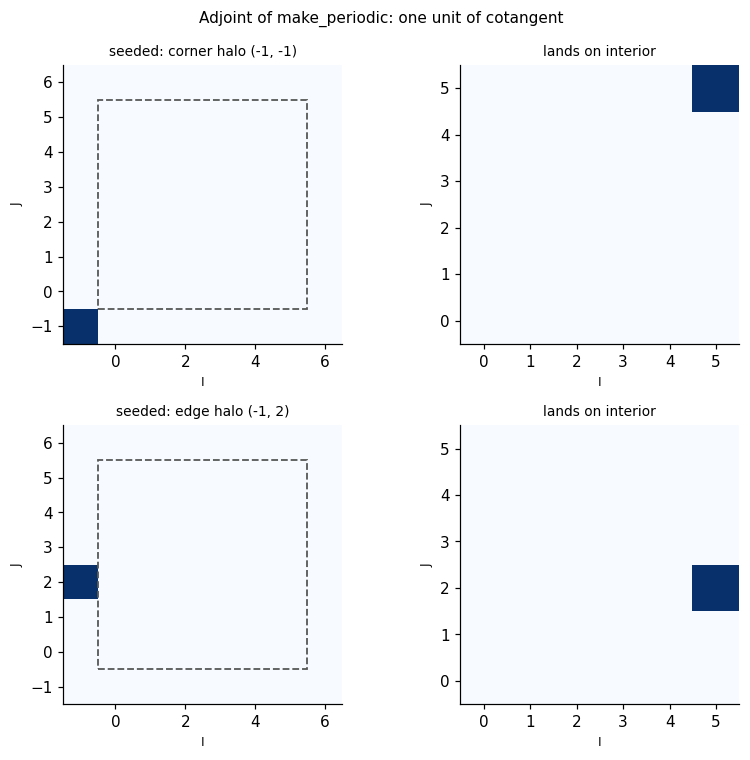

In [7]:
primal2, vjp2 = jax.vjp(lambda f: make_periodic(f, M, N), x2)


def seed(i, j):
    arr = jnp.zeros((M + 2, N + 2)).at[i + 1, j + 1].set(1.0)
    (g,) = vjp2(fld(DOM_HALO, arr))
    return np.asarray(arr), np.asarray(g.ndarray)


fig, axes = plt.subplots(2, 2, figsize=(7.6, 7.0))
for row, (i, j, label) in enumerate([(-1, -1, "corner halo (-1, -1)"),
                                     (-1, 2, "edge halo (-1, 2)")]):
    seeded, landed = seed(i, j)
    axes[row, 0].imshow(seeded.T, origin="lower", cmap="Blues", vmin=0, vmax=1,
                        extent=(-1.5, M + 0.5, -1.5, N + 0.5))
    axes[row, 0].add_patch(plt.Rectangle((-0.5, -0.5), M, N, fill=False,
                                         ec="0.35", lw=1.2, ls="--"))
    axes[row, 0].set_title(f"seeded: {label}", fontsize=9)
    axes[row, 1].imshow(landed.T, origin="lower", cmap="Blues", vmin=0, vmax=1,
                        extent=(-0.5, M - 0.5, -0.5, N - 0.5))
    axes[row, 1].set_title("lands on interior", fontsize=9)
    for ax in axes[row]:
        ax.grid(False)
        ax.set_xlabel("I", fontsize=8)
        ax.set_ylabel("J", fontsize=8)
fig.suptitle("Adjoint of make_periodic: one unit of cotangent", fontsize=10)
fig.tight_layout()
plt.show()

The corner halo cell `(-1, -1)` sends its cotangent to interior `(M-1, N-1)` — the
diagonally opposite corner, reached by composing the two reversed stages. The edge
halo cell `(-1, 2)` sends its cotangent to `(M-1, 2)`. Exactly the reverse of where
the forward exchange fetched from.

## 8. The operator a distributed code actually applies

`make_periodic` maps interior → halo, which is convenient but hides one of the two
mistakes we want to catch. A real halo update maps **halo → halo**: it overwrites the
halo from interior data and throws away whatever was in the halo before. That
discarding is a real part of the operator, and its adjoint is the zeroing.

`adjoint_operators.halo_exchange` is that version — restrict to the interior, then
re-fill the halo.

In [8]:
xh = fld(DOM_HALO, rng.standard_normal((M + 2, N + 2)))
yh = fld(DOM_HALO, rng.standard_normal((M + 2, N + 2)))

primal, vjp = jax.vjp(lambda f: halo_exchange(f, M, N), xh)
(ct_jax,) = vjp(yh)

lhs = float(jnp.sum(primal.ndarray * yh.ndarray))
rhs = float(jnp.sum(xh.ndarray * ct_jax.ndarray))
print(f"dot-product test on jax.vjp:  relative difference = {abs(lhs - rhs) / abs(lhs):.2e}")
print("\nadjoint of the halo lines (should be exactly zero):")
print(f"  I = -1 : {float(jnp.max(jnp.abs(ct_jax.ndarray[0, :]))):.1e}"
      f"    I = M : {float(jnp.max(jnp.abs(ct_jax.ndarray[-1, :]))):.1e}")
print(f"  J = -1 : {float(jnp.max(jnp.abs(ct_jax.ndarray[:, 0]))):.1e}"
      f"    J = N : {float(jnp.max(jnp.abs(ct_jax.ndarray[:, -1]))):.1e}")

dot-product test on jax.vjp:  relative difference = 7.14e-16

adjoint of the halo lines (should be exactly zero):
  I = -1 : 0.0e+00    I = M : 0.0e+00
  J = -1 : 0.0e+00    J = N : 0.0e+00


## 9. Writing the adjoint by hand, in the DSL

AD derived that transpose for us. Can we *write* it? This matters beyond curiosity:
it is the question of whether the adjoint of a halo exchange is expressible in field
view at all, or whether it needs a scatter primitive that the language does not have.

It is expressible. Reverse the stages, turn each copy into `g + g(shift)`, and zero
each halo line once its contribution has been collected.

In [9]:
print(inspect.getsource(halo_exchange_adjoint.definition))

@gtx.field_operator
def halo_exchange_adjoint(g: IJField, M: gtx.int32, N: gtx.int32) -> IJField:
    """Transpose of `halo_exchange`.

    Stages run in reverse order, each copy becomes an accumulation into the
    owner, and each halo line is zeroed once its contribution has been
    collected.
    """
    zero = 0.0 * g
    # reverse of  concat_where(J == N, f(J - N), f)
    g = concat_where(J == 0, g + g(J + N), g)
    g = concat_where(J == N, zero, g)
    # reverse of  concat_where(J == -1, f(J + N), f)
    g = concat_where(J == N - 1, g + g(J - N), g)
    g = concat_where(J == -1, zero, g)
    # reverse of  concat_where(I == M, f(I - M), f)
    g = concat_where(I == 0, g + g(I + M), g)
    g = concat_where(I == M, zero, g)
    # reverse of  concat_where(I == -1, f(I + M), f)
    g = concat_where(I == M - 1, g + g(I - M), g)
    g = concat_where(I == -1, zero, g)
    return g



In [10]:
ct_dsl = halo_exchange_adjoint(yh, M, N)
diff = float(jnp.max(jnp.abs(ct_dsl.ndarray - ct_jax.ndarray)))
rhs_dsl = float(jnp.sum(xh.ndarray * ct_dsl.ndarray))

print(f"max |DSL adjoint - jax.vjp|     = {diff:.2e}")
print(f"dot-product test on DSL adjoint = {abs(lhs - rhs_dsl) / abs(lhs):.2e}")

max |DSL adjoint - jax.vjp|     = 0.00e+00
dot-product test on DSL adjoint = 7.14e-16


Bit-for-bit identical to what `jax.vjp` produced. The adjoint of a halo exchange
stays inside the field view — gather in, gather out, no scatter primitive required.

That is a small instance of a much larger question: *is GT4Py's field view closed
under transposition?* For Cartesian shifts the answer is clearly yes, as here — a
shift by `+M` transposes to a shift by `-M`. The interesting open case is unstructured
neighbour reductions, where the transpose needs the reversed connectivity table.

## 10. Two ways to get it wrong

Both of these are mistakes people actually make in hand-written adjoint models, and
both produce a backward pass that runs perfectly happily.

- **No accumulation** — assign the halo cotangent onto the owner instead of adding
  it, discarding the owner's own contribution.
- **No zeroing** — accumulate correctly, but leave the halo cotangent sitting in the
  buffer, where the next operator upstream will count it a second time.

In [11]:
rows = [("correct", halo_exchange_adjoint),
        ("no accumulation", halo_exchange_adjoint_no_accumulate),
        ("no zeroing", halo_exchange_adjoint_no_zeroing)]

print(f"{'variant':>18} | {'<x, L^T y>':>18} | {'rel. error':>10} | {'max diff vs jax':>15}")
print("-" * 74)
for name, op in rows:
    g = op(yh, M, N)
    r = float(jnp.sum(xh.ndarray * g.ndarray))
    d = float(jnp.max(jnp.abs(g.ndarray - ct_jax.ndarray)))
    print(f"{name:>18} | {r:18.10e} | {abs(lhs - r) / abs(lhs):10.2e} | {d:15.2e}")
print(f"\nreference <Lx, y> = {lhs:.10e}")

           variant |         <x, L^T y> | rel. error | max diff vs jax
--------------------------------------------------------------------------
           correct |  -9.3265635665e-01 |   7.14e-16 |        0.00e+00
   no accumulation |  -2.4590384098e+00 |   1.64e+00 |        3.78e+00
        no zeroing |  -9.6631700479e+00 |   9.36e+00 |        2.84e+00

reference <Lx, y> = -9.3265635665e-01


The dot-product test catches both, and it catches them *loudly* — errors of a few
percent to tens of percent, not roundoff. This is the whole argument for running it.

Note what it took to expose the zeroing bug: the halo→halo framing from section 8.
Had we tested `make_periodic` alone — interior in, halo out — the input would have had
no halo to zero, the bug would have been invisible, and the test would have passed.
**Test the operator your model actually applies.**

## 11. The nonlinear check

Sections 5–10 exploited linearity. The model as a whole is not linear, so close the
loop with the standard test: a Taylor expansion of a scalar functional `J` around the
initial state, in a random direction `d`.

    r1 = |J(x + h d) - J(x)|                     = O(h)     — rate 1
    r2 = |J(x + h d) - J(x) - h <grad J, d>|     = O(h^2)   — rate 2

Rate 2 in the second column is what confirms the gradient. The forward model here is
ten leapfrog steps of the shallow water model, each of which ends in `make_periodic`,
so the halo adjoint is exercised ten times inside the backward pass.

In [12]:
Mt = Nt = 16
dx = dy = 100000.0
dt, radius, alpha = 90.0, 1000000.0, 0.001
N_STEPS = 10
DOM_T = interior_domain(Mt, Nt)


def forward(u0, v0, p0, n_steps):
    u, v, p = (make_periodic(f, Mt, Nt) for f in (u0, v0, p0))
    state = timestep(u, v, p, dx, dy, dt, u, v, p, 0.0, Mt, Nt)

    def step(carry, _):
        u, v, p, uo, vo, po = carry
        return timestep(u, v, p, dx, dy, 2.0 * dt, uo, vo, po, alpha, Mt, Nt), None

    final, _ = jax.lax.scan(step, state, None, length=n_steps - 1)
    return final[0], final[1], final[2]


def J_functional(u0, v0, p0):
    u, v, p = forward(u0, v0, p0, N_STEPS)
    return jnp.sum(u.ndarray**2) + jnp.sum(v.ndarray**2) + jnp.sum(p.ndarray**2)


_u, _v, _p = initialize_interior(np, Mt, Nt, dx, dy, radius)
state0 = tuple(fld(DOM_T, a) for a in (_u, _v, _p))

J0 = float(J_functional(*state0))
grads = jax.grad(J_functional, argnums=(0, 1, 2))(*state0)

direction = [fld(DOM_T, rng.standard_normal((Mt, Nt)) * float(jnp.std(f.ndarray)))
             for f in state0]
dJ = sum(float(jnp.sum(g.ndarray * d.ndarray)) for g, d in zip(grads, direction))

print(f"J(x)              = {J0:.8e}")
print(f"<grad J, d>       = {dJ:.8e}\n")
print(f"{'h':>10} {'r1':>14} {'r2':>14} {'rate1':>7} {'rate2':>7}")

hs, r1s, r2s = [], [], []
h, prev1, prev2 = 1e-2, None, None
for _ in range(8):
    pert = [fld(DOM_T, f.ndarray + h * d.ndarray) for f, d in zip(state0, direction)]
    Jh = float(J_functional(*pert))
    r1, r2 = abs(Jh - J0), abs(Jh - J0 - h * dJ)
    s1 = np.log2(prev1 / r1) if prev1 else float("nan")
    s2 = np.log2(prev2 / r2) if prev2 else float("nan")
    print(f"{h:10.2e} {r1:14.6e} {r2:14.6e} {s1:7.2f} {s2:7.2f}")
    hs.append(h); r1s.append(r1); r2s.append(r2)
    prev1, prev2, h = r1, r2, h / 2

J(x)              = 8.10021599e+11
<grad J, d>       = -2.01779769e+08

         h             r1             r2   rate1   rate2
  1.00e-02   2.012742e+06   5.055996e+03     nan     nan


  5.00e-03   1.007635e+06   1.263992e+03    1.00    2.00
  2.50e-03   5.041334e+05   3.159969e+02    1.00    2.00


  1.25e-03   2.521457e+05   7.899978e+01    1.00    2.00


  6.25e-04   1.260926e+05   1.974970e+01    1.00    2.00
  3.13e-04   6.305124e+04   4.937352e+00    1.00    2.00


  1.56e-04   3.152685e+04   1.234728e+00    1.00    2.00


  7.81e-05   1.576374e+04   3.089536e-01    1.00    2.00


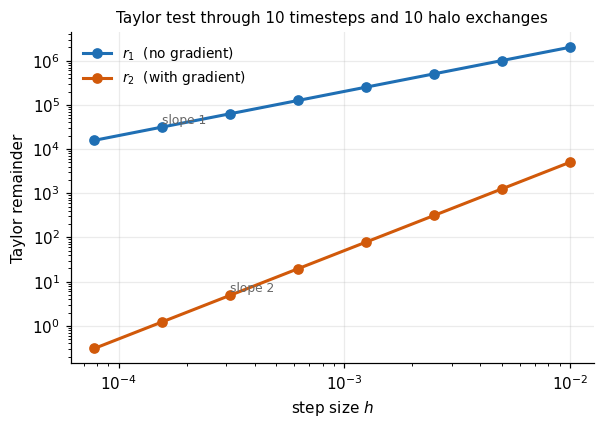

In [13]:
fig, ax = plt.subplots(figsize=(5.6, 4.0))
hs_a = np.array(hs)
ax.loglog(hs_a, r1s, "o-", color=BLUE, lw=2, ms=6, label="$r_1$  (no gradient)")
ax.loglog(hs_a, r2s, "o-", color=ORANGE, lw=2, ms=6, label="$r_2$  (with gradient)")
ax.loglog(hs_a, r1s[0] * (hs_a / hs_a[0]), "--", color="0.6", lw=1, zorder=0)
ax.loglog(hs_a, r2s[0] * (hs_a / hs_a[0]) ** 2, "--", color="0.6", lw=1, zorder=0)
ax.annotate("slope 1", (hs_a[-2], r1s[0] * (hs_a[-2] / hs_a[0])),
            color="0.4", fontsize=8, va="bottom")
ax.annotate("slope 2", (hs_a[-3], r2s[0] * (hs_a[-3] / hs_a[0]) ** 2),
            color="0.4", fontsize=8, va="bottom")
ax.set_xlabel("step size $h$")
ax.set_ylabel("Taylor remainder")
ax.set_title("Taylor test through 10 timesteps and 10 halo exchanges", fontsize=10)
ax.legend(frameon=False, fontsize=9)
fig.tight_layout()
plt.show()

Second-order convergence, clean over eight halvings. The gradient is right.

## 12. The dictionary

Everything above translates directly into the distributed setting:

| forward (halo fill) | adjoint (reverse exchange) |
|---|---|
| `recv` halo from the neighbour that owns it | `send` halo cotangent back to that owner |
| `halo = owner` (assignment) | `owner_bar += halo_bar` (**accumulation**) |
| old halo contents are discarded | `halo_bar = 0` after sending |
| phase `I`, then phase `J` | phase `J`, then phase `I` (**reversed**) |
| corners arrive via the second phase | corner cotangents leave via the first phase |

The middle two rows are the ones that get written wrong. Assignment instead of
accumulation loses the owner's own contribution; forgetting the zeroing double-counts
on the next exchange upstream.

## 13. What this does *not* yet show

The exchange here is periodic and single-process, so owner and halo live in the same
array and the accumulation is a local `+=`. Nothing has crossed a wire. Two things
are therefore still open:

- a real reverse exchange is a **reduction over the network**, not a local add;
- the tape here holds a full field per `concat_where` stage, where a distributed
  implementation would tape only the halo buffers.

`nb02_distributed_ad.ipynb` takes both on, and uses the numbers from this notebook as
the reference every distributed gradient has to reproduce.